Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


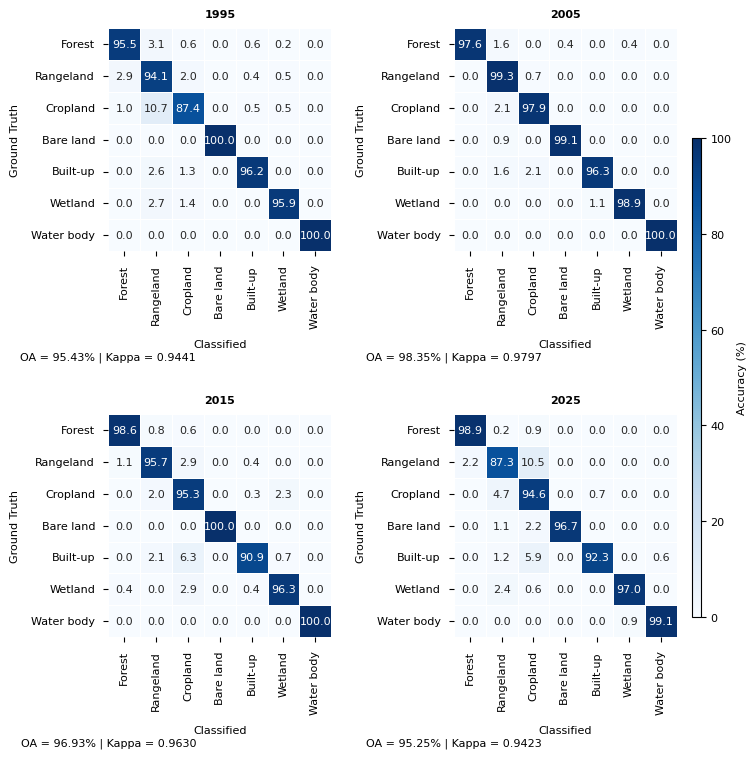

In [113]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, cohen_kappa_score

folder_path = '/content/drive/My Drive/tanganyikabasinbdi/'

years = [1995, 2005, 2015, 2025]

class_names = ["Forest", "Rangeland", "Cropland", "Bare land", "Built-up", "Wetland", "Water body"]

target_width_pixels = 2244
dpi = 300

fig_width = target_width_pixels / dpi
fig_height = 7.48

fig, axes = plt.subplots(2, 2, figsize=(fig_width, fig_height), constrained_layout=False)
axes = axes.flatten()

vmin = 0
vmax = 100

summary_metrics = []

for i, year in enumerate(years):
    file_path = os.path.join(folder_path, f'{year}_validation_points.csv')
    df = pd.read_csv(file_path)

    y_true = df['classValue'] - 1
    y_pred = df['classification'] - 1

    cm = confusion_matrix(y_true, y_pred, labels=range(7))

    cm_table = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_table.to_csv(f'/content/{year}_raw_confusion_matrix.csv')

    oa = np.trace(cm) / np.sum(cm)
    kappa = cohen_kappa_score(y_true, y_pred)

    user_acc = cm.diagonal() / cm.sum(axis=1)
    prod_acc = cm.diagonal() / cm.sum(axis=0)
    f1 = 2 * (user_acc * prod_acc) / (user_acc + prod_acc)

    metrics_table = pd.DataFrame({
        'Land_Cover_Class': class_names,
        'Users_Accuracy': np.round(user_acc * 100, 2),
        'Producers_Accuracy': np.round(prod_acc * 100, 2),
        'F1_Score': np.round(f1 * 100, 2)
    })
    metrics_table.to_csv(f'/content/{year}_accuracy_metrics.csv', index=False)

    summary_metrics.append({
        'Year': year,
        'Overall_Accuracy': round(oa * 100, 2),
        'Kappa_Coefficient': round(kappa, 4)
    })

    cm_norm = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100
    cm_norm = np.nan_to_num(cm_norm, nan=0.0)

    ax = axes[i]

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        vmin=vmin,
        vmax=vmax,
        square=True,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
        linewidths=0.5,
        linecolor='white',
        annot_kws={"size": 8, "ha": "center", "va": "center"},
        ax=ax
    )

    ax.set_title(year, fontsize=8, weight='bold', pad=8)
    ax.text(0, -0.45, f'OA = {oa*100:.2f}% | Kappa = {kappa:.4f}',
            transform=ax.transAxes, fontsize=8, ha='center', va='top')
    ax.set_xlabel('Classified', fontsize=8, labelpad=8)
    ax.set_ylabel('Ground Truth', fontsize=8, labelpad=8)
    ax.tick_params(axis='x', labelrotation=90, labelsize=8, pad=6)
    ax.tick_params(axis='y', rotation=0, labelsize=8, pad=6)

cbar_ax = fig.add_axes([0.92, 0.18, 0.012, 0.64])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Accuracy (%)', fontsize=8)
cbar.ax.tick_params(labelsize=8)

plt.subplots_adjust(left=0.14, right=0.90, top=0.99, bottom=0.13, wspace=0.55, hspace=0.5)

plt.savefig('/content/Confusion_Matrices.png', dpi=dpi, bbox_inches=None)
plt.show()

summary_df = pd.DataFrame(summary_metrics)
summary_df.to_csv('/content/Overall_Accuracy_Summary.csv', index=False)